## Importing Dependencies

In [ ]:
!pip install transformers

In [ ]:
# python
import re

# 3rd party
import pandas as pd
import nltk
from nltk.corpus import stopwords
from transformers import BartTokenizer, BartForConditionalGeneration, AdamW
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn import CrossEntropyLoss
from transformers import pipeline

## Uploading Dataset

In [ ]:
df=pd.read_csv('image_df.csv')
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Excellent!,I work in a bookstore and so these little gadg...,[{'small_image_url': 'https://m.media-amazon.c...,B07QC7JRDP,B07QC7JRDP,AEHWUHNTB5FX32HJ7UBOZ2WWUX3Q,1.652793e+12,0.0,True
1,1.0,"HIGHLY, HIGHLY OVERPRICED","wow, is this a rip off or what? after I cleane...",[{'small_image_url': 'https://m.media-amazon.c...,B0882ZJ48W,B0882ZJ48W,AGUWL2R2JFLC3K65HLD6AHJV3KBA,1.639714e+12,0.0,True
2,4.0,Works fine like every other filter I tried pre...,There are 40 #4 cone coffee filters in this pa...,[{'small_image_url': 'https://images-na.ssl-im...,B08F9VXZBM,B08F9VXZBM,AFXF3EGQTQDXMRLDWFU7UBFQZB7Q,1.624555e+12,1.0,False
3,5.0,Love everything about Nespresso except pod $..!!,01/23 update: trying a different brand of lids...,[{'small_image_url': 'https://m.media-amazon.c...,B09W3YPC6N,B09W3YPC6N,AEIPJBAN7A55Q5DFFPZSR2UV3OKA,1.661159e+12,20.0,False
4,5.0,Christmas Gift,My niece loved these!,[{'small_image_url': 'https://m.media-amazon.c...,B0B9J6P1PQ,B0B9J4TVR8,AGTFULIOVJK6RHUYWETEGSE5ITCQ,1.674510e+12,0.0,True


In [ ]:
filtered_df= df[df['rating'].isin([3.0,2.0,1.0])]

In [ ]:
filtered_df.head()
filtered_df.shape

(16265, 10)

In [ ]:
sampled_df = filtered_df.sample(n=500, random_state=42)


## Creating new column "Problem_of_product"

In [ ]:
# Load the zero-shot classification model
classifier = pipeline("zero-shot-classification")

# Define your labels (issues you want to extract)
labels = ["Quality issues", "Not as described", "Customer service", "Broken/Defective", "Poor performance"]

# Apply the classifier to each review in the DataFrame
def classify_review(text):
    result = classifier(text, candidate_labels=labels)
    return result["labels"][0]  # Get the top label (most likely issue)

# Assuming 'text' is the column with reviews in your DataFrame
sampled_df['problem_of_product'] = sampled_df['text'].apply(classify_review)

# Check the updated DataFrame
print(sampled_df.head())


No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

       rating                                      title  \
1455      1.0                        Not upgraded at all   
4500      3.0                               These are ok   
8769      1.0         Don't fit the ge xwf as advertised   
1119      1.0              The parts don't fit together!   
23567     1.0  Broke during the first wash - Cheap parts   

                                                    text  \
1455   The thermistor went in my 2016 Samsung DV350AE...   
4500   I like them once I got the measurements right....   
8769   These are not a fit for the ge xwf, the top ha...   
1119   The funnel looking thing (the adapter) is supp...   
23567  Water hose adapter which came with washer brok...   

                                                  images        asin  \
1455   [{'small_image_url': 'https://m.media-amazon.c...  B07M87YFJS   
4500   [{'small_image_url': 'https://m.media-amazon.c...  B09NTFX876   
8769   [{'small_image_url': 'https://images-na.ssl-im...  B07P

## Distribution of reviews among main issues

In [ ]:
sampled_df.groupby('problem_of_product').count()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
problem_of_product,,,,,,,,,,
Broken/Defective,172,172,172,172,172,172,172,172,172,172
Customer service,9,9,9,9,9,9,9,9,9,9
Not as described,185,185,185,185,185,185,185,185,185,185
Poor performance,90,90,90,90,90,90,90,90,90,90
Quality issues,44,44,44,44,44,44,44,44,44,44


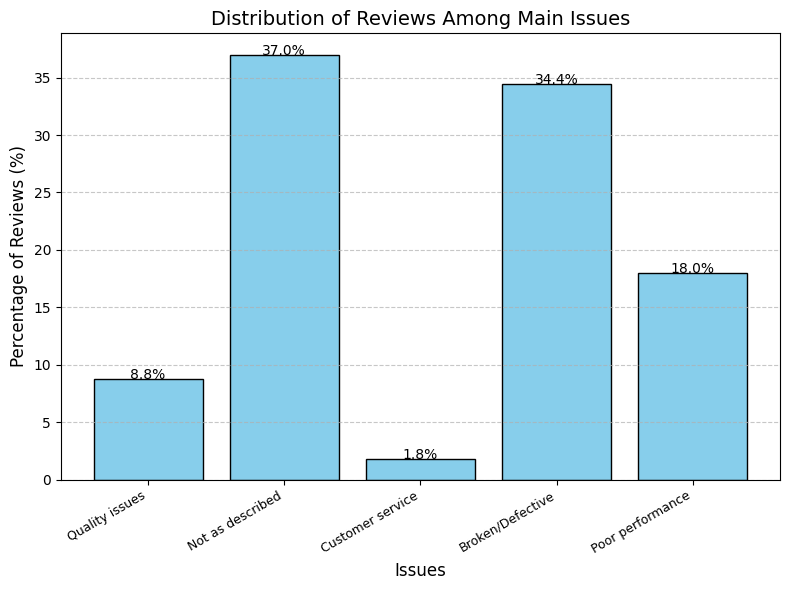

In [ ]:
import matplotlib.pyplot as plt

# Labels and values
labels = ["Quality issues", "Not as described", "Customer service", "Broken/Defective", "Poor performance"]
values = [44, 185, 9, 172, 90]

# Calculate percentages
total = sum(values)
percentages = [(value / total) * 100 for value in values]

# Create the bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, percentages, color='skyblue', edgecolor='black')

# Add percentage labels on top of each bar
for bar, percentage in zip(bars, percentages):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{percentage:.1f}%", ha='center', fontsize=10)

# Customize the chart
plt.title("Distribution of Reviews Among Main Issues", fontsize=14)
plt.ylabel("Percentage of Reviews (%)", fontsize=12)
plt.xlabel("Issues", fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


## Summary generation for Not as described reviews as the most recurrying issue




In [ ]:
import pandas as pd
df=pd.read_csv('categorized_df.csv')

In [ ]:
df.shape

(500, 12)

In [ ]:
# Filter reviews for the specific issue
issue = "Not as described"
filtered_reviews = df[df['problem_of_product'] == issue]
filtered_reviews=(filtered_reviews[filtered_reviews['helpful_vote']!=0]).sort_values(by='helpful_vote',ascending=False)

In [ ]:
summary_df=filtered_reviews.head(20)

In [ ]:
summary_df = summary_df.reset_index()
summary_df.head()

,index,Unnamed: 0,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,problem_of_product
0,369,6704,2.0,ARRIVED USED. That's not my hair attached to it.,I wish I could blather on about how cute this ...,[{'small_image_url': 'https://images-na.ssl-im...,B00EAY540S,B08FDC59PB,AF5YJNTEQXRYYFZHW4YZKDDN3FHQ,1586834239691,127,True,Not as described
1,419,35272,2.0,Get what you pay for,Installed easily in the GE model shown in phot...,[{'small_image_url': 'https://images-na.ssl-im...,B07MG765SH,B099ZZ83QZ,AHPPZZN6O2L5YQL7WACIJWMLC5JQ,1576785924789,123,True,Not as described
2,194,48944,3.0,It is what it is..,Direct OEM replacement.<br />NOTE: There are s...,[{'small_image_url': 'https://images-na.ssl-im...,B00DM8JYWC,B00DM8JYWC,AEOQ5ZIIATWFGS3JEFXJ6GXQCBHQ,1399747958000,109,True,Not as described
3,69,30036,1.0,Makes water dirty!,This filter makes my water dirtier! As you can...,[{'small_image_url': 'https://images-na.ssl-im...,B07QK53YP4,B0C61PCSGR,AFUMUDOLTCNLWJ5RWGVDI2FX45GQ,1583019642179,58,True,Not as described
4,355,40108,1.0,One Star,Do not buy this item. Doesn’t work and not the...,[{'small_image_url': 'https://images-na.ssl-im...,B013E8CIRC,B09VTZ54J7,AHUTSSCFPOAY6LWALBHIMWG5AXNQ,1517002211628,52,True,Not as described


In [ ]:
print(summary_df[summary_df['index']==419]['text'].values[0])

Installed easily in the GE model shown in photo. Beware the burst of water when you first activate your fridge to run water through the filter. Did not come with instructions, so I followed the instructions on the original GE filter I had installed. Ran 1.5 gallons of water through the system prior to use. I was able to purchase 3 of these for 1/2 the price of one GE filter. My system seemed to be oddly “over pressurized” with these filters and the water flow was not smooth and constant. When I removed this filter, it almost popped out of the socket, whereas the GE model is inserted and removed smoothly.<br /><br />Upon further examination I found these were manufactured in China and only tested to NSF/ANSI 42. Original GE model is tested to 42 and 53. NSF 42 is for aesthetic impurities and flavor/odor. NSF 53 is for actual contaminants with a health effect. I returned this item and ordered the more expensive, albeit more effective GE manufacturer filter. I can’t put a price on my fami

## Creating two types summaries manually(detailed and short summaries) for fine tunning Bart

In [ ]:

# Create a dictionary with index as the key and detailed summary as the value
summaries = {
    369:'summary',
    419:'summary',
    194:'summary',
    69:'summary',
    355: "The reviewer warns not to buy this item, stating it doesn't work and is not the correct replacement. They included photos showing the size difference between the old and new parts.",
    462: "The reviewer tested the filters with a Water Quality Tester and found the TDS level in the 320 range, similar to their tap water (340), instead of the expected 0-100 range. They are disappointed since they've been using the filters for 4 years and are now questioning their effectiveness, comparing it to Costco water (TDS 20). They await the company's response.",
    256: "The reviewer is frustrated with the product's return cost, which Amazon wanted nearly $7.00 to process, while the reviewer expected it to be no more than $2.00. Additionally, the warning on the product advising not to let the liner come in contact with flame seems inappropriate for its intended use, as it is needed for a store with constant heat. The reviewer suggests using foil paper instead, as it would serve a similar purpose.",
    18: "The reviewer is dissatisfied with the ice maker due to several issues: ice melting quickly because of lack of insulation, chemical taste from recycled ice, and inconsistent ice shapes (starting as bullets but eventually becoming tiny caps). Despite trying to fix the issues by using bottled water and storing ice separately, the product still failed to perform properly.",
    294: "The reviewer is disappointed because the kegerator arrived with dents, particularly on the door, which created sharp metal edges. Additionally, the CO2 gauge doesn't work properly, and the reviewer had difficulty reaching the seller for support, leading to frustration with the product's quality.",
    53: "The reviewer mentions that the replacement knob is too small and doesn't fit their Frigidaire/Electrolux stove. Despite having the same part number, the product is different and incorrect.",
    247: "The reviewer criticizes the ice maker for being inefficient due to poor insulation, causing watery ice that melts quickly. It also takes up more space than expected, has limited portability, and the ice basket fills up fast, making it impractical for frequent use. The product's high price is also seen as a downside.",
    284: "The review highlights that the pump was missing from the product, despite the photo showing a part that appears to be the pump impeller.",
    197: "The review indicates that the filter is not compatible with the 5231JA2006A LG filter despite the box labeling it as such. The reviewer feels that the label on the box is misleading, as the product doesn't actually fit or work as expected.",
    49: "The review highlights several issues with the washer. Despite its great appearance, large capacity, and easy operation, the lack of a spin-dry cycle—which was explicitly mentioned in the title—was a major disappointment. The reviewer also noted that the product arrived with scratches, black grease, a strong cigarette smell, and an unusually loud, knocking sound, raising concerns about its quality.",
    406: "The product's information often doesn't match what the user sees, making the app inconsistent. Despite this, the reviewer still considers it worth the $9 sale price but would have been disappointed at the original cost.",
    230: "The review points out that the magnetic elements of the cooking surface do not align with the markings, which is visible during boiling. Additionally, the oven door top flaps are poorly attached and detach during the first use.",
    41: "The review claims that the water filter is a fraud because it does not effectively filter water, as the ppm levels from the filter were the same as tap water.",
    210: "The review highlights that the EcoAqua filter is incompatible with the GSE23 refrigerator, causing reduced or stopped water flow and poor water taste, likely due to inadequate filtration.",
    3: "The review points out that the ice machine is defective, showing a false 'ice full' message, and the reviewer advises avoiding the product due to its unreliability.",
    255: "The review highlights that the Perfectpure filter’s poor construction led to ineffective filtration and a bad taste in the water, indicating quality control issues."
}

# Create the new 'summary' column by mapping the summaries to the corresponding index
summary_df['summary'] = summary_df['index'].map(summaries)


In [ ]:

# Create a dictionary with index as the key and shorter summary as the value
shorter_summaries = {
    369:'summary',
    419:'summary',
    194:'summary',
    69:'summary',
    355: "The reviewer warns not to buy this item, stating it does not match the description (wrong size, wrong replacement part).",
    462: "The reviewer found the TDS level in the 320 range, which contradicts the claimed 0-100 range in the description.",
    256: "The reviewer is frustrated with the $7.00 return cost, which was higher than expected based on the description.",
    18: "The reviewer is dissatisfied with the ice maker, citing quickly melting ice, chemical taste, and inconsistent shapes, which were not described.",
    294: "The kegerator arrived with dents and sharp edges, and the CO2 gauge doesn't work, which was not disclosed.",
    53: "The replacement knob is too small and doesn't fit the Frigidaire/Electrolux stove, contradicting the description.",
    247: "The ice maker is inefficient due to poor insulation and takes up more space than described.",
    284: "The pump was missing, though it was shown in the description and photos.",
    197: "The filter is not compatible with the 5231JA2006A LG filter, despite the description stating it was.",
     49: "The washer lacks the spin-dry cycle that was explicitly mentioned in the description.",
    406: "The product's description doesn't match what the user sees in the app, creating inconsistency.",
    230: "The magnetic elements don’t align, and the oven door flaps detach, which was not mentioned in the description.",
    41: "The water filter doesn't filter effectively, as claimed in the description.",
    210: "The EcoAqua filter is incompatible with the GSE23 refrigerator, despite the description claiming otherwise.",
     3: "The ice machine shows a false 'ice full' message, which wasn't mentioned in the description.",
    255: "The Perfectpure filter’s poor construction led to ineffective filtration, contradicting the description.",
}

# Create the new 'summary' column by mapping the summaries to the corresponding index
summary_df['shorter_summary'] = summary_df['index'].map(shorter_summaries)

## Preprocessing & Tokenizing text reviews



In [ ]:
import nltk

In [ ]:
import re

In [ ]:
# Ensure necessary NLTK data is downloaded
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
complete_text = summary_df['text']
summary = summary_df['summary']
summary = summary_df['shorter_summary']

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
def preprocess_for_abstractive(text, max_length=512):
    # Convert to lowercase
    if not isinstance(text, str):
        return ''
    text = text.lower()

    # Remove URLs and HTML tags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'<.*?>', '', text)

    # Tokenize and truncate to max_length
    tokens = nltk.word_tokenize(text)
    tokens = tokens[:max_length]  # Truncate

    # Join tokens back into text
    preprocessed_text = ' '.join(tokens)
    return preprocessed_text

In [ ]:
# Apply preprocessing to both columns
summary_df['processed_complete_text'] = summary_df['text'].apply(lambda x: preprocess_for_abstractive(x, max_length=512))
summary_df['processed_summary'] = summary_df['summary'].apply(lambda x: preprocess_for_abstractive(x, max_length=150))
summary_df['processed_shorter_summary'] = summary_df['shorter_summary'].apply(lambda x: preprocess_for_abstractive(x, max_length=150))

In [ ]:
# Load a tokenizer for the pre-trained model
tokenizer = BartTokenizer.from_pretrained('facebook/bart-base')

# Tokenize and encode the complete text and summaries
def tokenize_texts(texts, max_length=256):
    return tokenizer(
        texts.tolist(),  # Convert to list
        max_length=max_length,
        truncation=True,
        padding=True,
        return_tensors="pt"
    )

# Tokenize complete text and summaries
input_encodings = tokenize_texts(summary_df['processed_complete_text'], max_length=256)
summary_encodings = tokenize_texts(summary_df['processed_summary'], max_length=150)
shorter_summary_encodings = tokenize_texts(summary_df['processed_shorter_summary'], max_length=150)

print("Input Encodings:", input_encodings['input_ids'][:1])
print("Summary Encodings:", summary_encodings['input_ids'][:1])

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

Input Encodings: tensor([[    0,   118,  2813,   939,   115,  3089, 13860,    15,    59,   141,
         11962,    42,  3841,   254,    16,    36,   142,    24,    16,   269,
         11962,  4839,   479,    53,  2156,    24,  2035,   546,   341,    36,
         10667,  2156,   784,  2544,  2156, 10610,  1730,  2156,  1880,     7,
          4136, 34538,  2156, 11573,   293,    73,  3866,  6528,  5559,    73,
           417,  9211,    15, 14929,  2156,   103,  2345,     9, 33753,    15,
           233,     9,     5,  8633, 36237,     9,     5, 12638,  2156,     8,
             5,  2373,   233,    21,   380,   251,  2549,  8144,  1533,   498,
           198,    65,     9,     5, 34242,    19,    10,   380,  2125,   160,
         10199,    12,   219, 11671,  7391,     7,    24,   479,   939,    33,
          3493,     7,   458,    36,    53,   117,  1973,     7, 20021,   259,
           235,   122,  4839,     5,  1086,  3563,    36,  1025,     8,    66,
          4839,    56,  4678,  7727

In [ ]:
from sklearn.model_selection import train_test_split

# Filter rows with and without summaries
test_data = summary_df.iloc[:4]

# Assign train data (rows 5 to 20)
train_data = summary_df.iloc[4:]

# Split into features and targets
train_texts = train_data['processed_complete_text']
train_summaries = train_data['processed_summary']
test_texts = test_data['processed_complete_text']
test_summaries = test_data['processed_summary']  # This will be NaN or empty
  # Confirm splits
print(f"Training Samples: {len(train_texts)}")
print(f"Test Samples: {len(test_texts)}")


Training Samples: 16
Test Samples: 4


In [ ]:
from sklearn.model_selection import train_test_split

# Filter rows with and without summaries
test_data = summary_df.iloc[:4]

# Assign train data (rows 5 to 20)
train_data = summary_df.iloc[4:]

# Split into features and targets
train_texts = train_data['processed_complete_text']
train_summaries = train_data['processed_shorter_summary']
test_texts = test_data['processed_complete_text']
test_summaries = test_data['processed_shorter_summary']  # This will be NaN or empty
  # Confirm splits
print(f"Training Samples: {len(train_texts)}")
print(f"Test Samples: {len(test_texts)}")

Training Samples: 16
Test Samples: 4


In [ ]:
# Load a tokenizer for the pre-trained model
tokenizer = BartTokenizer.from_pretrained('facebook/bart-base')

# Tokenize and encode the complete text and summaries
def tokenize_texts(texts, max_length=512):
    return tokenizer(
        texts.tolist(),  # Convert to list
        max_length=max_length,
        truncation=True,
        padding=True,
        return_tensors="pt"
    )

# Tokenize and encode text
train_encodings = tokenize_texts(train_texts, max_length=512)
train_labels = tokenize_texts(train_summaries, max_length=256)

test_encodings = tokenize_texts(test_texts, max_length=512)
test_labels = tokenize_texts(test_summaries, max_length=256)

# Encoded data (input_ids) serves as embeddings for the model
print("Train Input IDs:", train_encodings['input_ids'][:1])
print("Train Attention Masks:", train_encodings['attention_mask'][:1])
print("Test Input IDs:", test_labels['input_ids'][:1])

Train Input IDs: tensor([[    0,  5016,    45,   907,    42,  6880,   479,   630,    44,    27,
           326,   173,     8,    45,     5,  4577,  5010,   479,    47,    64,
           192,    31,   127,  2356,   479,     5,    65,   939,    56,    16,
            15,     5,   235,     8,     5,    65,   939,    21,  1051,    16,
            15,     5,   314,   479,    47,    64,  2563,   192,     5, 11269,
         14247,    15,     5,  2380,    32,   430,   479,     2,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1

In [ ]:
# Load a tokenizer for the pre-trained model
tokenizer = BartTokenizer.from_pretrained('facebook/bart-base')

# Tokenize and encode the complete text and summaries
def tokenize_texts(texts, max_length=512):
    return tokenizer(
        texts.tolist(),  # Convert to list
        max_length=max_length,
        truncation=True,
        padding=True,
        return_tensors="pt"
    )

# Tokenize and encode text
train_encodings = tokenize_texts(train_texts, max_length=512)
train_labels = tokenize_texts(train_summaries, max_length=256)

test_encodings = tokenize_texts(test_texts, max_length=512)
test_labels = tokenize_texts(test_summaries, max_length=256)

# Encoded data (input_ids) serves as embeddings for the model
print("Train Input IDs:", train_encodings['input_ids'][:1])
print("Train Attention Masks:", train_encodings['attention_mask'][:1])
print("Test Input IDs:", test_labels['input_ids'][:1])

Train Input IDs: tensor([[    0,  5016,    45,   907,    42,  6880,   479,   630,    44,    27,
           326,   173,     8,    45,     5,  4577,  5010,   479,    47,    64,
           192,    31,   127,  2356,   479,     5,    65,   939,    56,    16,
            15,     5,   235,     8,     5,    65,   939,    21,  1051,    16,
            15,     5,   314,   479,    47,    64,  2563,   192,     5, 11269,
         14247,    15,     5,  2380,    32,   430,   479,     2,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1

## Finetunning Bart model based on existing summaries and create summary for rest of reviews

In [ ]:
# Load the pre-trained BART model
model = BartForConditionalGeneration.from_pretrained('facebook/bart-base')

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

In [ ]:
# Custom Dataset class
class SummarizationDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.encodings['input_ids'])

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels['input_ids'][idx]
        }

# Create datasets
train_dataset = SummarizationDataset(train_encodings, train_labels)
test_dataset = SummarizationDataset(test_encodings, test_labels)

In [ ]:
import torch
from torch.utils.data import DataLoader
from transformers import BartForConditionalGeneration, BartTokenizer, AdamW


# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Hyperparameters
num_epochs = 3
batch_size = 4
learning_rate = 5e-5

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# Define optimizer
optimizer = AdamW(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        # Move batch data to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        total_loss += loss.item()

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader)}")

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/3, Loss: 8.907147884368896
Epoch 2/3, Loss: 7.424010157585144
Epoch 3/3, Loss: 6.5181883573532104


In [ ]:
import torch
from torch.utils.data import DataLoader
from transformers import BartForConditionalGeneration, BartTokenizer, AdamW


# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Hyperparameters
num_epochs = 3
batch_size = 4
learning_rate = 5e-5

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# Define optimizer
optimizer = AdamW(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        # Move batch data to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        total_loss += loss.item()

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader)}")

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/3, Loss: 6.339850306510925
Epoch 2/3, Loss: 4.958756685256958
Epoch 3/3, Loss: 4.121389269828796


In [ ]:
# Save the fine-tuned model
model.save_pretrained("./fine_tuned_bart")
tokenizer.save_pretrained("./fine_tuned_bart")

/usr/local/lib/python3.10/dist-packages/transformers/modeling_utils.py:2817: UserWarning: Moving the following attributes in the config to the generation config: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


('./fine_tuned_bart/tokenizer_config.json',
 './fine_tuned_bart/special_tokens_map.json',
 './fine_tuned_bart/vocab.json',
 './fine_tuned_bart/merges.txt',
 './fine_tuned_bart/added_tokens.json')

## Getting 2 types of summaries for rest of the reviews

In [ ]:
# Evaluation
model.eval()
generated_summaries = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        # Generate summaries
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_length=150,
            num_beams=4,
            early_stopping=True
        )

        # Decode summaries
        decoded_summaries = [
            tokenizer.decode(output, skip_special_tokens=True) for output in outputs
        ]
        generated_summaries.extend(decoded_summaries)

# Print summaries for the test set
for idx, summary in enumerate(generated_summaries):
    print(f"Review {idx+1} Summary: {summary}")

Review 1 Summary: the reviewer is disappointed with the dryer because it arrived with a lot of rust , lint , and wet wipe down residue ( as if someone had taken soaking wet cloths and rubbed the machine down ) . the reviewer also noted that the product had a small amount of lint on the filter , a small piece of fabric-y garbage attached to it , a large piece of the drum with a big piece of garbage attached , and an obvious wet wipe-down residue .
Review 2 Summary: installed easily in the ge model , whereas the original ge filter failed to run water through the filter , causing the filter to pop out of the socket . the filter also failed to fit properly , resulting in a “ health effect ” . the reviewer also noted that the filter did not fit properly in the socket , making it difficult for the reviewer to use the filter .
Review 3 Summary: direct oem replacement.note : there are some online cross references that shows this part ( frigidaire 134844410 selector knob ) as something that wou

In [ ]:
# Evaluation
model.eval()
generated_summaries = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        # Generate summaries
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_length=150,
            num_beams=4,
            early_stopping=True
        )

        # Decode summaries
        decoded_summaries = [
            tokenizer.decode(output, skip_special_tokens=True) for output in outputs
        ]
        generated_summaries.extend(decoded_summaries)

# Print summaries for the test set
for idx, summary in enumerate(generated_summaries):
    print(f"Review {idx+1} Shorter-Summary: {summary}")

Review 1 Shorter-Summary: the dryer does not match the description .
Review 2 Shorter-Summary: the ge filter does not fit the ge model , despite the description .
Review 3 Shorter-Summary: the selector knob does not fit the frigidaire gallery series model , despite the description .
Review 4 Shorter-Summary: the filter does not filter the filter , despite the description .
